# Real-Time Bitcoin Sentiment Analysis

This notebook demonstrates a pipeline for scraping Bitcoin-related tweets, preprocessing them with spaCy, performing sentiment analysis, correlating with Bitcoin prices, and visualizing the results.

## Overview of Steps
1. **Data Ingestion**: Scrape real-time Bitcoin-related tweets using Selenium.
2. **Data Preprocessing**: Clean and preprocess tweets using spaCy for tokenization, stop-word removal, lemmatization, and Named Entity Recognition (NER).
3. **Correlation with Bitcoin Prices**: Fetch Bitcoin price data from CoinGecko and compute the correlation with sentiment scores.
4. **Visualizations**: Plot sentiment scores and Bitcoin price trends over time.

## Step 1: Data Ingestion - Scrape Tweets

We use the `BitcoinSentimentAnalyzer` class to scrape tweets containing the keyword 'Bitcoin'.

In [3]:
from Bitcoin_API import BitcoinSentimentAnalyzer
import pandas as pd

# Initialize the analyzer with the ChromeDriver path and X credentials
analyzer = BitcoinSentimentAnalyzer(
    chromedriver_path=r"C:\Users\siddh\Downloads\new working dr for 605\chromedriver.exe",  # Replace with your ChromeDriver path
    x_username="siddhirohantest",  # Replace with your X username
    x_password="testing@123"   # Replace with your X password
)

# Scrape tweets
tweets = analyzer.scrape_tweets(keyword="Bitcoin", max_tweets=50)

# Store tweets in a DataFrame
tweets_df = pd.DataFrame(tweets)
tweets_df.head()

,text,timestamp
0,More than that. Ryan fugger created ripplepay ...,2025-05-16T03:43:18.306309
1,反感を買うために言うん好きww,2025-05-16T03:43:18.316302
2,Future is multi-chain:\n•Ethereum: fin layer &...,2025-05-16T03:43:18.328303
3,All signs pointing to a new high.,2025-05-16T03:43:18.336313
4,Good use of money?,2025-05-16T03:43:20.377313


## Step 2: Data Preprocessing - Clean and Preprocess Tweets

We preprocess the tweets using spaCy for tokenization, stop-word removal, lemmatization, and Named Entity Recognition (NER). Sentiment analysis is also performed to assign scores and categorize tweets.

In [4]:
# Preprocess tweets
processed_tweets = analyzer.preprocess_tweets(tweets)

# Analyze sentiment
tweets_with_sentiment = analyzer.analyze_sentiment(processed_tweets)

# Store processed tweets with sentiment in a DataFrame
processed_df = pd.DataFrame(tweets_with_sentiment)
processed_df[['text', 'sentiment', 'sentiment_category', 'coins']].head()

,text,sentiment,sentiment_category,coins
0,ryan fugger create ripplepay year like bitcoin,0.5574,positive,[]
1,ww,0.0000,neutral,[]
2,future multi chain \n ethereum fin layer rollu...,0.3400,positive,"[Cardano, Bitcoin]"
3,sign point new high,0.0000,neutral,[]
4,good use money,0.4404,positive,[]


## Step 3: Correlation with Bitcoin Prices - Fetch Prices and Analyze Correlation

We fetch Bitcoin price data from CoinGecko, store it with sentiment scores, and compute the correlation.

In [5]:
# Fetch Bitcoin price data
price_df = analyzer.fetch_bitcoin_price()

# Correlate sentiment with price
combined_df, correlation = analyzer.correlate_sentiment_price(tweets_with_sentiment, price_df)

print(f"Correlation between sentiment and Bitcoin price: {correlation:.4f}")
combined_df.head()

Correlation between sentiment and Bitcoin price: -0.0742


,timestamp,sentiment,timestamp,price
0,2025-05-16 03:43:18.306309,0.5574,2025-05-15 08:06:31.852,101919.802688
1,2025-05-16 03:43:18.316302,0.0000,2025-05-15 08:10:53.918,101938.979778
2,2025-05-16 03:43:18.328303,0.3400,2025-05-15 08:15:56.396,101956.569906
3,2025-05-16 03:43:18.336313,0.0000,2025-05-15 08:21:34.136,102013.524131
4,2025-05-16 03:43:20.377313,0.4404,2025-05-15 08:26:05.600,102029.480660


## Step 4: Visualizations - Plot Sentiment and Price Trends

We create a line plot to visualize sentiment scores and Bitcoin price trends over time.

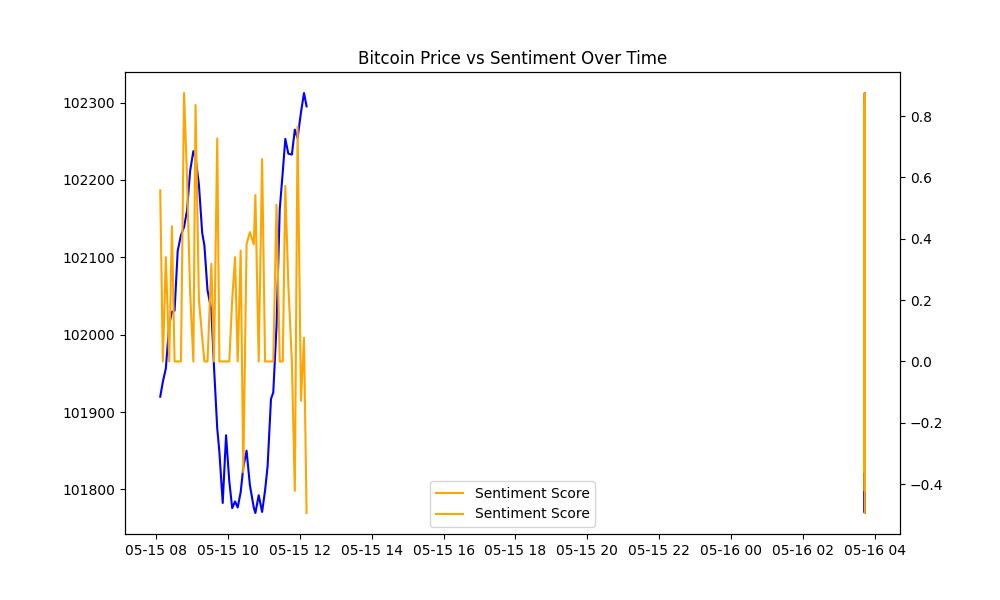

In [6]:
# Visualize the data
analyzer.visualize_data(combined_df)

# Display the plot
from IPython.display import Image
Image(filename='sentiment_price_plot.png')